# 31 — Modal Pipeline Test

Tests the full `run_experiment()` flow — capture → save → upload → spawn_map — using
dummy camera/audio functions against real experiment-20 data. No hardware required.

In [ ]:
%load_ext autoreload
%autoreload 2
%aimport -modal
%aimport -modal_proto
%aimport -synchronicity

import sys, os, json, time, shutil, threading
from datetime import datetime, timezone
from pathlib import Path
import numpy as np

sys.path.append("/home/ethantu/workspace/good-vibrations/src3")

from io_utils import save, load, append, preview, Timing, copy_output_to_sample, copy_audio_to_sample, get_box_coverage_key
from overhead_pipeline import (
    app as segmenter_app,
    capture_overhead, process_overhead, visualize_overhead
)
from vibrations_pipeline import (
    app as vibrations_app,
    volume, process_vibrations_modal, process_vibrations_modal_localdata, capture_vibrations,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'io_utils'

In [ ]:
# Start both Modal apps and keep them alive for the session.
# segmenter_app  = modal.App("segment") — SAM segmentation for overhead images
# vibrations_app = modal.App("pclk")    — GPU phase correlation for vibrations
_segmenter_ctx  = segmenter_app.run.aio()
_vibrations_ctx = vibrations_app.run.aio()
await _segmenter_ctx.__aenter__()
await _vibrations_ctx.__aenter__()

[modal-client] 2026-06-18T22:01:09+0300 Loop attempt for _run_app.<locals>.heartbeat failed
Traceback (most recent call last):
  File "/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/modal/_utils/async_utils.py", line 571, in loop_coro
    await asyncio.wait_for(async_f(), timeout=timeout)
  File "/home/ethantu/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/asyncio/tasks.py", line 520, in wait_for
    return await fut
           ^^^^^^^^^
  File "/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/modal/runner.py", line 66, in _heartbeat
    await client.stub.AppHeartbeat(request, retry=Retry(attempt_timeout=HEARTBEAT_TIMEOUT))
modal.exception.ServiceError: Authorization check failed: <AioRpcError of RPC that terminated with:
	status = StatusCode.DEADLINE_EXCEEDED
	details = "Deadline Exceeded"
	debug_error_string = "UNKNOWN:Error received from peer  {grpc_message:"Deadline Exceeded", grpc_status:4, created_time:

In [6]:
EXPERIMENT_DIR  = Path('/home/ethantu/workspace/good-vibrations/experiment-20/data')
BASE_SAMPLE_DIR = EXPERIMENT_DIR / 'samples'
BASE_OUTPUT_DIR = EXPERIMENT_DIR / 'outputs'
AUDIO_PATH      = Path('/home/ethantu/workspace/good-vibrations/assets/chirp_50_1000_3.0sec.wav')

VIBRATION_FILES = ["01_raw_shifts.npy", "02_clean_shifts.npy", "03_fft_shifts.npz", "04_recovered_audio.wav", "05_processed_fft.npy"]
SYMLINKS = [("recovered_audio.wav", "inputs/04_recovered_audio.wav"), ("X.npy", "inputs/05_processed_fft.npy")]

def count_dirs(path): return sum(1 for p in path.iterdir() if p.is_dir()) if path.exists() else 0
def make_id(path): return f"{count_dirs(path):06d}"

In [7]:
def modal_upload(sample_dir):
    sample_id = sample_dir.name
    with Timing(f"[sample {sample_id}] upload raw vibrations from DISK to modal volume: "):
        with volume.batch_upload(force=True) as batch:
                batch.put_file(sample_dir / 'inputs/00_raw_vibrations.npy', f"{sample_dir.name}/inputs/00_raw_vibrations.npy")
                batch.put_file(sample_dir / 'metadata.jsonl', f"{sample_dir.name}/metadata.jsonl")

In [8]:
def modal_download(remote_path, local_path):
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    with open(local_path, 'wb') as f:
        for chunk in volume.read_file(str(remote_path)): f.write(chunk)

def fix_symlinks(sample_dir):
    for dst_rel, src_rel in SYMLINKS:
        dst, src = sample_dir / dst_rel, sample_dir / src_rel
        if dst.exists() or dst.is_symlink(): dst.unlink()
        dst.symlink_to(src.relative_to(dst.parent))

In [ ]:
def show_box_coverage(box_coverage:dict, sample_dir:str|Path=None, verbose:int=1):
    metadata = {'sample_id': ''} if sample_dir is None else {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    with Timing(f"[Sample {metadata['sample_id']}] box coverage: ", enabled=verbose>=2):
        if sample_dir is not None:
            mask = np.array(load(sample_dir / "outputs/02_segment_mask.png"))

            # update box coverage
            key = get_box_coverage_key(metadata, mask)
            if key not in box_coverage: box_coverage[key] = {'mask': np.zeros(mask.shape), 'sample_ids': []}
            box_coverage[key]['mask'] += mask
            box_coverage[key]['sample_ids'].append(metadata['sample_id'])

            keys = [key]
        else:
            keys = box_coverage.keys()

    return box_coverage

In [ ]:
# def process_vibrations_all(sample_dir, audio_path, save_thread=None, do_save:bool=True, verbose:int=1):
#     sample_id = sample_dir.name

#     # save raw vibrations from RAM -> DISK
#     with Timing(f'[sample {sample_id}] save raw vibrations to {sample_dir / "inputs/00_raw_vibrations.npy"}: ', enabled=verbose >= 1):
#         if save_thread:
#             save_thread.join()
#             timestamp = datetime.now(timezone.utc).isoformat()
#             append({"save_vibrations": timestamp}, sample_dir / "times.jsonl", do_save)
#             append({"sample_id": sample_id, "time": timestamp}, audio_path.parent / "samples.jsonl", do_save)

#     # upload raw vibrations from local DISK to modal
#     with Timing(f'[sample {sample_id}] upload raw vibrations to modal volume: ', enabled=verbose >= 1):
#         with volume.batch_upload(force=True) as batch:
#             batch.put_file(sample_dir / 'inputs/00_raw_vibrations.npy', f"{sample_dir.name}/inputs/00_raw_vibrations.npy")
#             batch.put_file(sample_dir / 'metadata.jsonl', f"{sample_dir.name}/metadata.jsonl")
#         upload_timestamp = datetime.now(timezone.utc).isoformat()

#     # process raw vibrations
#     with Timing(f'[sample {sample_id}] process vibrations on modal: ', enabled=verbose >= 1):
#         process_vibrations_modal.remote(sample_dir.name, pclk_batch_size=1024, pclk_mode='sequential', verbose=verbose)

#     # download processed vibrations from modal to local DISK
#     with Timing(f'[sample {sample_dir.name}] download processed vibrations to {sample_dir}: ', enabled=verbose >= 1):
#         for f in VIBRATION_FILES: modal_download(f"{sample_dir.name}/inputs/{f}", sample_dir / f"inputs/{f}")
#         fix_symlinks(sample_dir)
#         append({"modal_upload": upload_timestamp}, sample_dir / "times.jsonl", do_save)
#         append({"modal_download": datetime.now(timezone.utc).isoformat()}, sample_dir / "times.jsonl", do_save)

In [ ]:
def save_and_process_vibrations(raw_vibrations:np.ndarray, sample_dir:Path, audio_path:Path, do_save:bool=True, verbose:int=1):
    sample_id = sample_dir.name

    # save raw vibrations from RAM -> DISK
    raw_vibration_path = sample_dir / 'inputs/00_raw_vibrations.npy'
    with Timing(f'[sample {sample_id}] save raw vibrations RAM->DISK to {raw_vibration_path}: ', enabled=verbose >= 1):
        save(raw_vibrations, raw_vibration_path, do_save)
        timestamp = datetime.now(timezone.utc).isoformat()
        append({"save_vibrations": timestamp}, sample_dir / "times.jsonl", do_save)
        append({"sample_id": sample_id, "time": timestamp}, audio_path.parent / "samples.jsonl", do_save)
        del raw_vibrations

    # upload raw vibrations from local DISK to modal
    with Timing(f'[sample {sample_id}] upload raw vibrations DISK->modal_volume: ', enabled=verbose >= 1):
        with volume.batch_upload(force=True) as batch:
            batch.put_file(sample_dir / 'inputs/00_raw_vibrations.npy', f"{sample_dir.name}/inputs/00_raw_vibrations.npy")
            batch.put_file(sample_dir / 'metadata.jsonl', f"{sample_dir.name}/metadata.jsonl")
        upload_timestamp = datetime.now(timezone.utc).isoformat()

    # process raw vibrations
    with Timing(f'[sample {sample_id}] process vibrations on modal: ', enabled=verbose >= 1):
        process_vibrations_modal.remote(sample_dir.name, pclk_batch_size=1024, pclk_mode='sequential', verbose=verbose)

    # download processed vibrations from modal to local DISK
    with Timing(f'[sample {sample_id}] download processed vibrations modal_volume->DISK to {sample_dir}: ', enabled=verbose >= 1):
        for f in VIBRATION_FILES: modal_download(f"{sample_dir.name}/inputs/{f}", sample_dir / f"inputs/{f}")
        fix_symlinks(sample_dir)
        append({"modal_upload": upload_timestamp}, sample_dir / "times.jsonl", do_save)
        append({"modal_download": datetime.now(timezone.utc).isoformat()}, sample_dir / "times.jsonl", do_save)

In [ ]:
def run_experiment(
    obj_params, audio_params, overhead_camera_params, laser_camera_params,
    box_coverage, cam, overhead_cam,
    capture_image_fxn, play_audio_fxn, capture_n_frames_fxn,
    verbose: int = 1, do_save: bool = True,
):
    # setup
    output_id = make_id(BASE_OUTPUT_DIR)
    output_dir = BASE_OUTPUT_DIR / output_id
    is_empty_box = obj_params['n_objects'] == 0
    speakers_list = sp if isinstance(sp := audio_params.pop('speakers_list'), list) else [sp]
    resize_params, out_h, out_w, prompt = overhead_camera_params['resize_params'], overhead_camera_params['out_h'], overhead_camera_params['out_w'], overhead_camera_params['prompt']

    metadata = obj_params | overhead_camera_params | laser_camera_params | dict(output_dir=str(output_dir), output_id=output_id, is_empty_box=is_empty_box)
    append([{k: v} for k, v in metadata.items()], output_dir / 'metadata.jsonl', do_save)

    total, used, free = shutil.disk_usage(EXPERIMENT_DIR)
    if verbose >= 1: print(f'[output {output_id}] {free / 2**30:.2f} GB free')

    cloud_threads = []

    with Timing(f'[output {output_id}] total: ', enter=f'[output {output_id}] start', enabled=verbose >= 1):
        # capture overhead image
        raw_overhead = capture_overhead(overhead_cam, capture_image_fxn, output_dir, do_save=do_save)

        # process overhead image on modal
        process_overhead(raw_overhead, output_dir, **resize_params, out_h=out_h, out_w=out_w, prompt=prompt, is_empty_box=is_empty_box, verbose=verbose, do_save=do_save)

        # loop over all speakers
        sample_dirs = []
        for speakers in speakers_list:
            # setup
            sample_id = make_id(BASE_SAMPLE_DIR)
            sample_dir = BASE_SAMPLE_DIR / sample_id
            sample_dirs.append(sample_dir)
            with Timing(f'[sample {sample_id}] total: ', enter=f'\n[sample {sample_id}] start', enabled=verbose >= 1):
                copy_output_to_sample(sample_dir, output_dir, verbose, do_save=do_save)
                copy_audio_to_sample(sample_dir, audio_params['audio_path'], verbose, do_save=do_save)

                # overhead image viz
                if verbose >= 1: preview(visualize_overhead(speakers, sample_dir, output_dir, is_empty_box, verbose, do_save=do_save), 'image')

                # box coverage viz
                if verbose >= 1: preview((show_box_coverage(box_coverage, sample_dir, verbose), sample_dir), 'box_coverage')

                # capture vibrations
                raw_vibrations = capture_vibrations(cam, speakers, play_audio_fxn, capture_n_frames_fxn, audio_params['audio_path'], sample_dir,
                                laser_camera_params['height'], laser_camera_params['width'], laser_camera_params['n_capture_seconds'] laser_camera_params['fps'],
                                verbose=verbose, do_save=do_save)

                # vibration viz
                if verbose >= 1: preview(raw_vibrations, 'vibration_image')

                # save and process vibrations async on modal
                t = threading.Thread(target=save_and_process_vibrations, args=(raw_vibrations, sample_dir, audio_params['audio_path'], do_save, verbose), daemon=True)
                t.start()
                cloud_threads.append(t)

    return sample_dirs, cloud_threads

## Dummy functions (stand-ins for real camera / audio hardware)

In [11]:
import subprocess

_audio_proc = None

def play_audio_fxn(audio_input, speakers, wait=True):
    global _audio_proc
    if _audio_proc and _audio_proc.poll() is None:
        _audio_proc.terminate()
    _audio_proc = subprocess.Popen(['aplay', str(audio_input)])
    if wait:
        _audio_proc.wait()


def capture_n_frames_fxn(cam, n_frames, *args):
    raw = load(BASE_SAMPLE_DIR / '000000' / 'inputs' / '00_raw_vibrations.npy')
    T = raw.shape[0]
    if n_frames <= T: return raw[:n_frames], None
    return np.tile(raw, (-(n_frames // -T), 1, 1))[:n_frames], None

def capture_image_fxn(cam):
    from PIL import Image
    import cv2
    img = load(BASE_SAMPLE_DIR / '000000' / 'outputs' / '00_raw_overhead.png')
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR), None

class DummyCam:
    def get_im_size(self): return [1056, 300]  # (W, H) from experiment-20 metadata

overhead_cam = None
cam = DummyCam()

metadata_000 = {k: v for d in load(BASE_SAMPLE_DIR / '000000' / 'metadata.jsonl') for k, v in d.items()}
run_opt = metadata_000['run_opt']

print(f"cam FPS: {run_opt['cam_params']['camera_FPS']}  |  n ROIs: {len(metadata_000['roi'])}")

cam FPS: 2500  |  n ROIs: 100


## Run experiment

[output 000036] 95.19 GB free
[output 000036] start
[output 000036] Box is not empty
[output 000036] resize the overhead image:  19.32 ms
[output 000036] segment the overhead image: 33283.83 ms
[output 000036] downsample the overhead image:   0.49 ms
[output 000036] com=(28.946496815286626, 225.79872611464967)	downsampled_com=(5.394677729909504, 44.76549282843075)
[output 000036] center of mass of the overhead image:   0.25 ms

[sample 000085] start
[sample 000085] symlink artifacts:   0.41 ms
[sample 000085] make viz of the overhead image:  19.55 ms


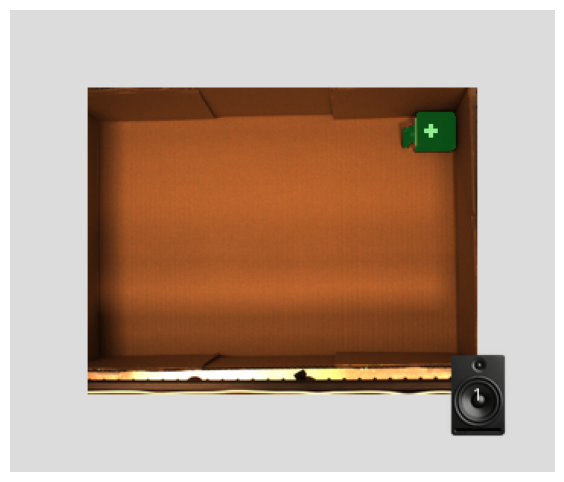

Playing WAVE '/home/ethantu/workspace/good-vibrations/assets/chirp_50_1000_3.0sec.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono


[sample 000085] captured 7750 frames
[sample 000085] record vibrations: 3100.20 ms


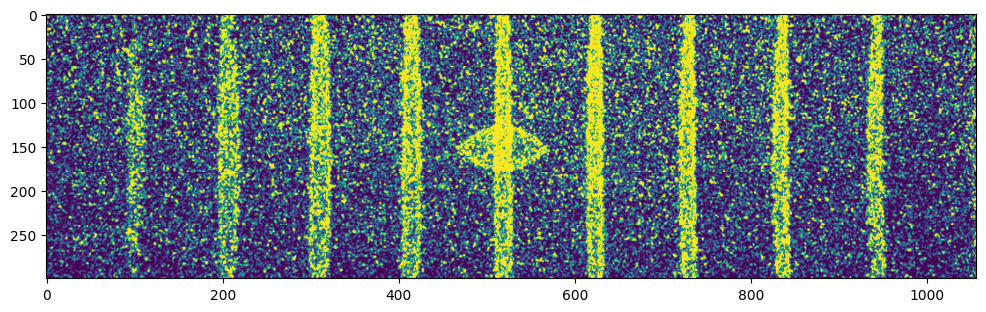

[sample 000085] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000085/inputs/00_raw_vibrations.npy:   0.00 ms[sample 000085] total: 3531.67 ms


[sample 000086] start
[sample 000086] symlink artifacts:  10.46 ms
[sample 000086] make viz of the overhead image:  19.92 ms


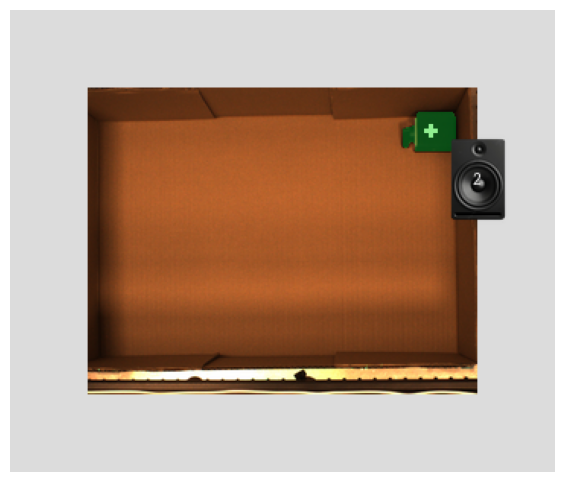

Playing WAVE '/home/ethantu/workspace/good-vibrations/assets/chirp_50_1000_3.0sec.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono


[sample 000086] captured 7750 frames
[sample 000085] upload raw vibrations to modal volume: 2906.53 ms
[sample 000086] record vibrations: 3100.45 ms


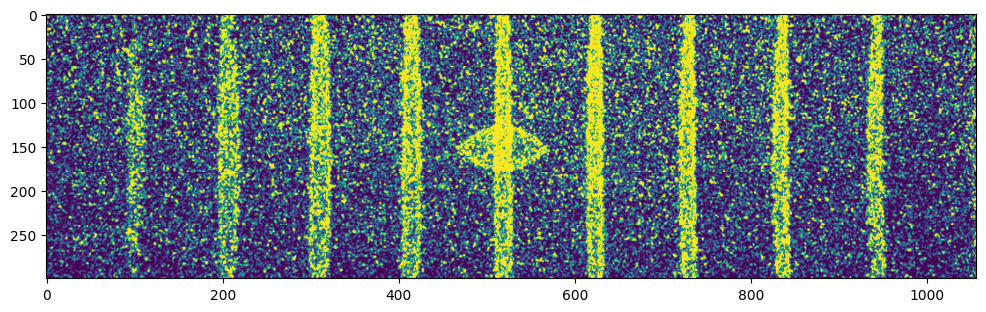

[sample 000086] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000086/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000086] total: 3539.42 ms

[sample 000087] start
[sample 000087] symlink artifacts:   0.62 ms
[sample 000087] make viz of the overhead image:  19.61 ms


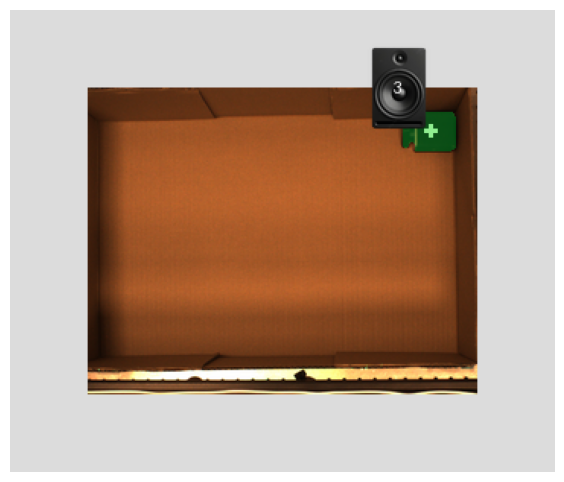

Playing WAVE '/home/ethantu/workspace/good-vibrations/assets/chirp_50_1000_3.0sec.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono


[sample 000087] captured 7750 frames
[sample 000086] upload raw vibrations to modal volume: 2341.23 ms
[sample 000087] record vibrations: 3100.59 ms


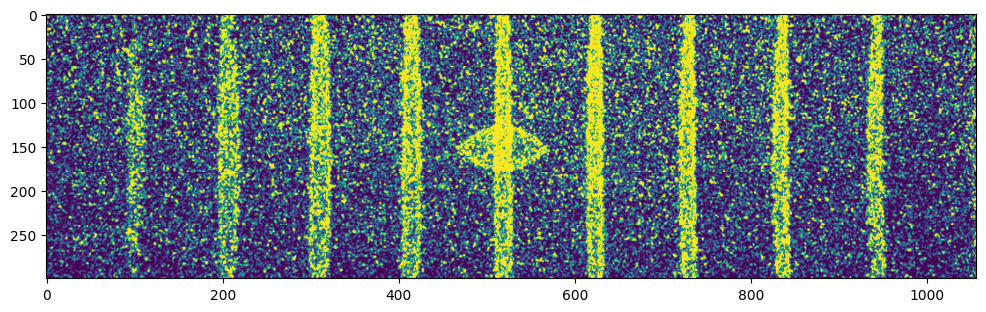

[sample 000087] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000087/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000087] total: 3531.97 ms
[output 000036] total: 44655.19 ms
Still working! 3 cloud threads running.


[sample 000087] upload raw vibrations to modal volume: 2023.60 ms


In [ ]:
obj_params = dict(object='cube', n_objects=1, box='cardboard')
audio_params = dict(
    audio_path=AUDIO_PATH,
    speakers_list=[1, 2, 3],  # one speaker = one sample, faster for testing
)
overhead_camera_params = dict(
    prompt="A black metal cube sitting on the floor of an open cardboard box from a bird's eye view.",
    description="A black metal cube sitting on the floor of an open cardboard box from a bird's eye view.",
    resize_params={"left": 0.14, "right": 0.7, "up": 0.06, "down": 0.65, "max_side": 256},
    out_h=40, out_w=51,
)

height, width = height= *cam.get_im_size()[::-1]
laser_camera_params = dict(
    roi=metadata_000['roi'],
    laser_camera_fps=metadata_000['laser_camera_fps'],
    n_capture_seconds=3.1,
    height=height,
    width=width,
    run_opt=run_opt,
    run_opt_multiROIs=metadata_000['run_opt_multiROIs'],
)

sample_dirs, cloud_threads = run_experiment(
    obj_params, audio_params, overhead_camera_params, laser_camera_params,
    box_coverage={}, cam=cam, overhead_cam=overhead_cam,
    capture_image_fxn=capture_image_fxn,
    play_audio_fxn=play_audio_fxn,
    capture_n_frames_fxn=capture_n_frames_fxn,
    verbose=2, do_save=True,
)

active = [t for t in cloud_threads if t.is_alive()]
if active: print(f"Still working! {len(active)} cloud threads running.")
else: print("All done!")

In [15]:
for t in cloud_threads: t.join()

[sample 000082] process vibrations on modal: 120791.64 ms
[sample 000083] process vibrations on modal: 122906.84 ms
[sample 000082] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000082: 6385.56 ms
[sample 000084] process vibrations on modal: 123307.65 ms
[sample 000083] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000083: 4650.41 ms
[sample 000084] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000084: 4495.35 ms


# Run Backlog

In [22]:
import tqdm

In [24]:
sample_dirs = [BASE_SAMPLE_DIR / f"{i:06d}" for i in range(72)]
for sample_dir in tqdm.tqdm(sample_dirs):
    metadata = {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    process_vibrations_all(sample_dir, Path(metadata['output_dir']), audio_params['audio_path'])

  0%|                                                                                                                                                                                          | 0/72 [00:00<?, ?it/s]

[sample 000000] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000000/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000000] upload raw vibrations to modal volume: 1883.93 ms
[sample 000000] process vibrations on modal: 118902.38 ms


  1%|██▍                                                                                                                                                                            | 1/72 [02:06<2:29:17, 126.16s/it]

[sample 000000] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000000: 5368.86 ms
[sample 000001] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000001/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000001] upload raw vibrations to modal volume: 2887.37 ms
[sample 000001] process vibrations on modal: 122727.95 ms


  3%|████▊                                                                                                                                                                          | 2/72 [04:17<2:30:34, 129.06s/it]

...

[sample 000069] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000069: 6375.93 ms
[sample 000070] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000070/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000070] upload raw vibrations to modal volume: 60058.30 ms
[sample 000070] process vibrations on modal: 91899.55 ms


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 71/72 [3:35:57<02:47, 167.20s/it]

[sample 000070] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000070: 7087.56 ms
[sample 000071] save raw vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000071/inputs/00_raw_vibrations.npy:   0.00 ms
[sample 000071] upload raw vibrations to modal volume: 52293.95 ms
[sample 000071] process vibrations on modal: 94190.60 ms


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 72/72 [3:38:30<00:00, 182.08s/it]

[sample 000071] download processed vibrations to /home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000071: 6401.42 ms


In [ ]:
# run this to close modal apps
#***** OTHERWISE it costs $$******
await _segmenter_ctx.__aexit__(None, None, None)
await _vibrations_ctx.__aexit__(None, None, None)